<a href="https://colab.research.google.com/github/MacUpr/ML/blob/main/Minera%C3%A7%C3%A3o_de_Dados_(Pr%C3%A9_processamento).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Curso de Especialização de Engenharia de Software Inteligente**
## Faculdade de Computação - Universidade Federal de Mato Grosso do Sul

**Mineração de Dados - Pré-processamento**

Referências/Agradecimentos: Professor Ricardo Marcacini - Universidade de São Paulo

In [ ]:
import pandas as pd
import numpy as np

# =====================================================
# GERANDO UMA BASE FICTÍCIA
# =====================================================

np.random.seed(42)

n = 100

dados = pd.DataFrame({
    "idade": np.random.randint(18, 70, n),
    "salario": np.random.normal(5000, 1500, n),
    "tempo_empresa": np.random.randint(1, 20, n),
    "cidade": np.random.choice(
        ["Campo Grande", "Dourados", "Três Lagoas"],
        n
    )
})

In [ ]:
# =====================================================
# CRIANDO ATRIBUTO REDUNDANTE
# =====================================================

dados["salario_copia"] = dados["salario"] * 1.02

# =====================================================
# CRIANDO ATRIBUTO DE BAIXA VARIÂNCIA
# =====================================================

dados["estado"] = "MS"

# =====================================================
# INSERINDO VALORES FALTANTES
# =====================================================

dados.loc[[3, 8, 15, 22], "idade"] = np.nan
dados.loc[[10, 30, 50], "salario"] = np.nan

# =====================================================
# INSERINDO OUTLIER
# =====================================================

dados.loc[5, "salario"] = 50000

In [ ]:
# =====================================================
# VISUALIZAÇÃO INICIAL
# =====================================================

print("\nPrimeiros registros")
print(dados.head(10))

print("\nDimensão")
print(dados.shape)


Primeiros registros
   idade       salario  tempo_empresa        cidade  salario_copia estado
0   56.0   2186.484842             10      Dourados    2230.214539     MS
1   69.0   2949.826792              3   Três Lagoas    3008.823328     MS
2   46.0   5954.457663              7  Campo Grande    6073.546816     MS
3    NaN   3639.918997             16  Campo Grande    3712.717377     MS
4   60.0   5714.063881             16  Campo Grande    5828.345159     MS
5   25.0  50000.000000             17      Dourados    7094.601741     MS
6   38.0   5317.380518              2      Dourados    5423.728129     MS
7   56.0   5895.566969              1   Três Lagoas    6013.478309     MS
8    NaN   3655.497225             16   Três Lagoas    3728.607170     MS
9   40.0   4832.018269             12   Três Lagoas    4928.658635     MS

Dimensão
(100, 6)


In [ ]:
print(dados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   idade          96 non-null     float64
 1   salario        97 non-null     float64
 2   tempo_empresa  100 non-null    int64  
 3   cidade         100 non-null    object 
 4   salario_copia  100 non-null    float64
 5   estado         100 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 4.8+ KB
None


In [ ]:
print(dados.describe()) #quartis

           idade       salario  tempo_empresa  salario_copia
count  96.000000     97.000000     100.000000     100.000000
mean   43.447917   5488.035186       9.320000    5159.592975
std    15.102366   4807.700305       6.068431    1557.933377
min    19.000000   2090.133172       1.000000    2131.935836
25%    31.000000   3838.935604       3.000000    3913.549768
50%    42.000000   4878.321569       9.000000    5003.210969
75%    57.000000   6086.124877      16.000000    6246.750245
max    69.000000  50000.000000      19.000000    9603.805027


In [ ]:
#Substituindo todos os dados faltantes da coluna idade pela média
dados["idade"] = dados["idade"].fillna(
    dados["idade"].mean()
)

dados["salario"] = dados["salario"].fillna(dados["salario"].mean())

In [ ]:
print(dados.isnull().sum()) #Valores faltantes

idade            0
salario          0
tempo_empresa    0
cidade           0
salario_copia    0
estado           0
dtype: int64


In [ ]:
#Análise de correlação
corr = dados.select_dtypes(include=np.number).corr()

print(corr)

                  idade   salario  tempo_empresa  salario_copia
idade          1.000000 -0.137295      -0.162921      -0.060511
salario       -0.137295  1.000000       0.092512       0.423182
tempo_empresa -0.162921  0.092512       1.000000      -0.089909
salario_copia -0.060511  0.423182      -0.089909       1.000000


In [ ]:
dados = dados.drop(columns=["salario_copia"])

In [ ]:
#Análise de variância
print(dados.nunique())

idade            46
salario          98
tempo_empresa    19
cidade            3
estado            1
dtype: int64


In [ ]:
dados = dados.drop(columns=["estado"])

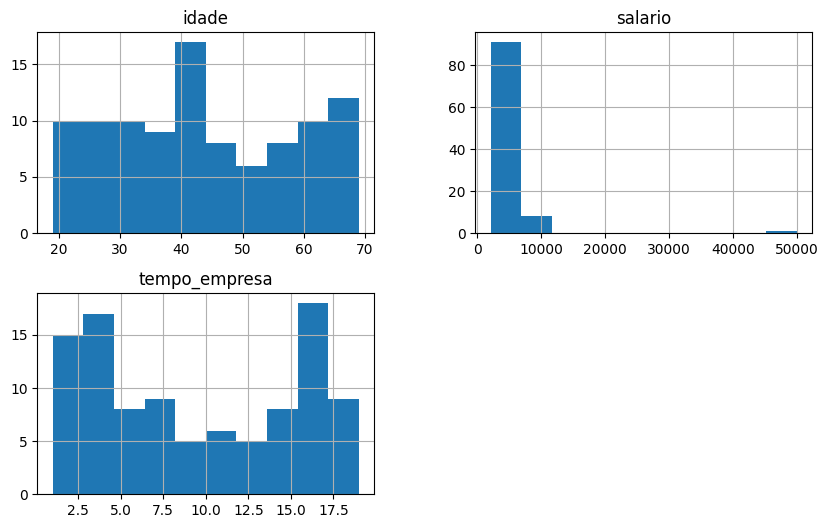

In [ ]:
import matplotlib.pyplot as plt

#Existe assimetria? Existe outlier?
dados.hist(figsize=(10,6))
plt.show()

In [ ]:
#Identificando outliers

Q1 = dados["salario"].quantile(0.25)
Q3 = dados["salario"].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers = dados[
    dados["salario"] > limite_superior
]

print(outliers)


    idade       salario  tempo_empresa       cidade
5    25.0  50000.000000             17     Dourados
51   67.0   9415.495125              6  Três Lagoas


**Mineração de Texto - Pré-processamento**

In [ ]:
# Importando bibliotecas
import pandas as pd
import string
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('rslp')
from nltk.tokenize import word_tokenize
from nltk.stem.porter import *
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import cosine
import numpy as np
import networkx as nx
!pip install plotly.express
from plotly import graph_objs as go

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


**Exemplo de Remoção de Stopwords**

In [ ]:
nltk.corpus.stopwords.words('portuguese')

['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'às',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele',
 'deles',
 'depois',
 'do',
 'dos',
 'e',
 'é',
 'ela',
 'elas',
 'ele',
 'eles',
 'em',
 'entre',
 'era',
 'eram',
 'éramos',
 'essa',
 'essas',
 'esse',
 'esses',
 'esta',
 'está',
 'estamos',
 'estão',
 'estar',
 'estas',
 'estava',
 'estavam',
 'estávamos',
 'este',
 'esteja',
 'estejam',
 'estejamos',
 'estes',
 'esteve',
 'estive',
 'estivemos',
 'estiver',
 'estivera',
 'estiveram',
 'estivéramos',
 'estiverem',
 'estivermos',
 'estivesse',
 'estivessem',
 'estivéssemos',
 'estou',
 'eu',
 'foi',
 'fomos',
 'for',
 'fora',
 'foram',
 'fôramos',
 'forem',
 'formos',
 'fosse',
 'fossem',
 'fôssemos',
 'fui',
 'há',
 'haja',
 'hajam',
 'hajamos',
 'hão',
 'havemos',
 'haver',
 'hei',
 'houve',
 'houvemos',
 'houver',
 'houvera',
 'houverá',
 'houveram',
 'houvéramos',
 'houverão',
 'houverei',
 'houverem',
 'hou

In [ ]:
nltk.corpus.stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
# remoção de pontuacao e stopwords

def remove_stopwords(text,lang,domain_stopwords=[]):

  stop_words = nltk.corpus.stopwords.words(lang) # lang='portuguese' or lang='english'

  s = str(text).lower() # tudo para caixa baixa
  table = str.maketrans({key: None for key in string.punctuation})
  s = s.translate(table) # remove pontuacao
  tokens = word_tokenize(s) #obtem tokens
  v = [i for i in tokens if not i in stop_words and not i in domain_stopwords and not i.isdigit()] # remove stopwords
  s = ""
  for token in v:
    if len(token) >= 4:
      s += token+" "
  return s.strip()


# exemplos de uso
text = "O estudante de Inteligência Artificial foi na livraria comprar  livros para estudar."
text2 = remove_stopwords(text, 'portuguese')
print('Antes: '+text)
print('Depois: '+text2)

Antes: O estudante de Inteligência Artificial foi na livraria comprar  livros para estudar.
Depois: estudante inteligência artificial livraria comprar livros estudar


**Exemplo de Stemming/Radicalização de Termos**

In [ ]:
# stemming
def stemming(text,lang):

  stemmer = PorterStemmer() # stemming para ingles

  if lang=='portuguese':
    stemmer = nltk.stem.RSLPStemmer() # stemming para portuguese

  tokens = word_tokenize(text) #obtem tokens

  sentence_stem = ''
  doc_text_stems = [stemmer.stem(i) for i in tokens]
  for stem in doc_text_stems:
    sentence_stem += stem+" "

  return sentence_stem.strip()


# exemplos de uso
text = "O estudante de Inteligência Artificial foi na livraria comprar livros para estudar."
text2 = remove_stopwords(text, 'portuguese')
text3 = stemming(text2, 'portuguese')
print('Antes: '+text)
print('Depois: '+text3)

Antes: O estudante de Inteligência Artificial foi na livraria comprar livros para estudar.
Depois: estud intelig artific livr compr livr estud


**Coletando uma Base de Textos para Testar**

In [ ]:
import urllib.parse
# obtendo dataset com uma amostra de textos

query = "febre amarela" # query para consultar
query = urllib.parse.quote(query)

url = 'http://websensors.net.br/minicurso/2019/eventos-br-2017.php?q='+query
print(url)

http://websensors.net.br/minicurso/2019/eventos-br-2017.php?q=febre%20amarela


In [ ]:
!wget '{url}' -O dados.csv

--2026-06-03 01:05:09--  http://websensors.net.br/minicurso/2019/eventos-br-2017.php?q=febre%20amarela
Resolving websensors.net.br (websensors.net.br)... 129.121.3.177
Connecting to websensors.net.br (websensors.net.br)|129.121.3.177|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘dados.csv’

dados.csv               [            <=>     ]   2.84M  1.15MB/s    in 2.5s    

2026-06-03 01:05:12 (1.15 MB/s) - ‘dados.csv’ saved [2979374]



In [ ]:
dataset = pd.read_csv('dados.csv',sep='\t')
dataset

,event_id,date,title,local,url,lat,lng
0,b4b29e9b5537c1896129029bd976438c,2017-01-05 15:27:28,"Após 2ª morte por febre amarela em SP, vacinaç...",Ribeirao Preto (SP),http://g1.globo.com/sp/ribeirao-preto-franca/n...,-21.17,-47.81
1,125bf6fbeef15b17a1d4837127129bbe,2017-01-08 16:04:51,Casos de febre amarela em macacos na região pr...,Ribeirao Preto (SP),http://g1.globo.com/sao-paulo/sao-jose-do-rio-...,-21.17,-47.81
2,aff14d48f09878b31e0575971fc8fec2,2017-01-08 14:04:51,G1 - Casos de febre amarela em macacos na regi...,Sao Jose do Rio Preto (SP),http://g1.globo.com/sao-paulo/sao-jose-do-rio-...,-20.82,-49.37
3,ca7ca58720fc9a2338894095ba6409f0,2017-01-05 13:27:28,"Após 2ª morte por febre amarela em SP, vacinaç...",Sao Jose do Rio Preto (SP),http://g1.globo.com/sp/ribeirao-preto-franca/n...,-20.82,-49.37
4,2a6e78e1226fc9c5f1c9061febf175d1,2017-01-09 14:57:25,Mortes por febre amarela põem em alerta cidade...,Sao Jose do Rio Preto (SP),http://istoe.com.br/mortes-por-febre-amarela-p...,-20.82,-49.37
...,...,...,...,...,...,...,...
8641,061b9b603b8043696558f309ab184857,2017-12-14 15:59:34,Febre amarela já matou dez pessoas e 501 macac...,Mairipora (SP),http://www.atribuna.com.br/noticias/noticias-d...,-23.31,-46.58
8642,b3a86762a53202cc32b8773051a63b48,2017-12-11 15:15:00,Postos ainda têm vacinas contra Febre Amarela ...,Hortolandia (SP),http://liberal.com.br/cidades/hortolandia/post...,-22.85,-47.22
8643,a2aa3d517698a0c4586705b95cda38c2,2017-12-13 19:03:18,Febre amarela: veja lista de postos de vacinaç...,Embu (SP),https://g1.globo.com/sp/sao-paulo/noticia/febr...,-23.64,-46.85
8644,b6f07b1d0d4aebf8f518a1060567ceca,2017-05-10 21:45:08,Confirmado primeiro caso de febre amarela em p...,Paulo Afonso (BA),https://g1.globo.com/bahia/noticia/confirmado-...,-9.40,-38.22


In [ ]:
# filtrando apenas o título
dataset = dataset[['title']].sample(1000)
dataset

,title
8366,Mogi das Cruzes amplia para 17 locais de vacin...
6475,Saúde divulga Informe Epidemiológico da Febre ...
5349,Estado de São Paulo registra nove mortes por f...
6411,Saúde divulga Informe Epidemiológico da Febre ...
7188,Hemorio vacina contra a febre amarela esta semana
...,...
8182,Cidades da região vão vacinar contra a febre a...
1120,Subsecretário espera que números da febre amar...
7694,Valinhos anuncia mutirão de vacinação contra a...
3983,Vacinação contra febre amarela em cidade no RJ...


In [ ]:
dataset.reset_index(drop=True,inplace=True)

In [ ]:
dataset

,title
0,Mogi das Cruzes amplia para 17 locais de vacin...
1,Saúde divulga Informe Epidemiológico da Febre ...
2,Estado de São Paulo registra nove mortes por f...
3,Saúde divulga Informe Epidemiológico da Febre ...
4,Hemorio vacina contra a febre amarela esta semana
...,...
995,Cidades da região vão vacinar contra a febre a...
996,Subsecretário espera que números da febre amar...
997,Valinhos anuncia mutirão de vacinação contra a...
998,Vacinação contra febre amarela em cidade no RJ...


**Computando uma Bag-of-Words**

In [ ]:
# obtendo a bag-of-words
def compute_bag_of_words(dataset,lang,domain_stopwords=[]):

  d = []
  for index,row in dataset.iterrows():
    text = row['title'] #texto do evento
    text2 = remove_stopwords(text, lang,domain_stopwords)
    text3 = stemming(text2, lang)
    d.append(text3)

  matrix = CountVectorizer(max_features=100)
  X = matrix.fit_transform(d)

  count_vect_df = pd.DataFrame(X.todense(), columns=matrix.get_feature_names_out())

  return count_vect_df


bow = compute_bag_of_words(dataset,'portuguese')
bow

,abr,ach,alt,amarel,ampl,ampli,ano,anunc,após,aument,...,sob,sobr,surt,suspeit,trê,vacin,vej,vitór,zon,áre
0,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
996,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
998,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
bow[['febr']]

,febr
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


In [ ]:
list(bow.columns)

['abr',
 'ach',
 'alt',
 'amarel',
 'ampl',
 'ampli',
 'ano',
 'anunc',
 'após',
 'aument',
 'bah',
 'blog',
 'brasil',
 'camp',
 'campanh',
 'campin',
 'cas',
 'caus',
 'cheg',
 'cidad',
 'começ',
 'confirm',
 'contr',
 'correi',
 'descart',
 'distribu',
 'divulg',
 'diári',
 'doi',
 'dos',
 'emerg',
 'epidemiológ',
 'est',
 'exam',
 'examecom',
 'febr',
 'fech',
 'fil',
 'folh',
 'geral',
 'globocom',
 'govern',
 'grand',
 'hemori',
 'human',
 'imuniz',
 'inform',
 'interi',
 'investig',
 'jorn',
 'jundiaí',
 'lev',
 'list',
 'macac',
 'mat',
 'milhã',
 'min',
 'minist',
 'mor',
 'morr',
 'mort',
 'municípi',
 'mut',
 'nest',
 'nov',
 'númer',
 'parqu',
 'paul',
 'pesso',
 'popul',
 'post',
 'prefeit',
 'prim',
 'priorit',
 'proc',
 'quas',
 'receb',
 'recomend',
 'reforç',
 'reg',
 'registr',
 'risc',
 'salv',
 'sant',
 'saúd',
 'secret',
 'segund',
 'seman',
 'sesp',
 'situ',
 'sob',
 'sobr',
 'surt',
 'suspeit',
 'trê',
 'vacin',
 'vej',
 'vitór',
 'zon',
 'áre']

**Ponderação de Termos com TFIDF**

In [ ]:
# obtendo a VSM com TFIDF
def compute_vsm_tfidf(dataset,lang,domain_stopwords=[]):

  d = []
  for index,row in dataset.iterrows():
    text = row['title'] #texto do evento
    text2 = remove_stopwords(text, lang,domain_stopwords)
    text3 = stemming(text2, lang)
    d.append(text3)

  matrix = TfidfVectorizer(max_features=100)
  X = matrix.fit_transform(d)

  tfidf_vect_df = pd.DataFrame(X.todense(), columns=matrix.get_feature_names_out())

  return tfidf_vect_df


vsm = compute_vsm_tfidf(dataset,'portuguese')
vsm

,abr,ach,alt,amarel,ampl,ampli,ano,anunc,após,aument,...,sob,sobr,surt,suspeit,trê,vacin,vej,vitór,zon,áre
0,0.0,0.0,0.0,0.171860,0.827971,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.342440,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.163886,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.112550,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.163886,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.126436,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.251931,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.116815,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.232760,0.0,0.0,0.0,0.0
996,0.0,0.0,0.0,0.217159,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
997,0.0,0.0,0.0,0.114921,0.000000,0.0,0.0,0.623313,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.228986,0.0,0.0,0.0,0.0
998,0.0,0.0,0.0,0.190783,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.380144,0.0,0.0,0.0,0.0


In [ ]:
vsm[['amarel']]

,amarel
0,0.171860
1,0.163886
2,0.112550
3,0.163886
4,0.126436
...,...
995,0.116815
996,0.217159
997,0.114921
998,0.190783


**Dissimilaridade de cosseno (1-cos) entre dois textos**

In [ ]:
# computando dissimilaridade de cosseno

def dis_cosine(matrix, e1, e2):
  dcos = cosine(matrix.iloc[e1,:], matrix.iloc[e2,:])
  return dcos


# exemplo: dissimilaride entre o primeiro (id=0) e o segundo evento (id=1) do vsm-tfidf
dis_cosine(vsm,1,2)

np.float64(0.9631091481925811)

In [ ]:
# dissimilaridade entre documento 1 e os outros 1 até 10

for i in range(1,10):
  print('doc=',i,dis_cosine(vsm,1,i))

doc= 1 0.0
doc= 2 0.9631091481925811
doc= 3 0.0
doc= 4 0.9585577768027979
doc= 5 0.9202273057672163
doc= 6 0.0
doc= 7 0.9572771740648501
doc= 8 0.9589608768070867
doc= 9 0.96793171415456


In [ ]:
input = 3
print('Entrada =',dataset.iloc[input].title)
for index2,row2 in vsm.iterrows():
    dcos = dis_cosine(vsm,input,index2)
    if dcos > 0 and dcos <= 0.3:
      text = dataset.iloc[index2].title
      print(input,index2,dcos,text)

Entrada = Saúde divulga Informe Epidemiológico da Febre Amarela
3 454 0.21236584292875949 Saúde divulga Informe Epidemiológico sobre a Febre Amarela
3 734 0.21236584292875949 Saúde divulga Informe Epidemiológico sobre a febre amarela
3 788 0.21236584292875949 Saúde divulga informe epidemiológico sobre a febre amarela
3 852 0.21236584292875949 Saúde divulga Informe Epidemiológico sobre a Febre Amarela
